<a href="https://colab.research.google.com/github/evjeeenji/Serial_killers/blob/main/serials_killers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Завантажуємо файл вже з датами народжень
from google.colab import files


serial_killers_birth = files.upload()

Saving Serial_killers_data.xlsx to Serial_killers_data.xlsx


In [2]:
import pandas as pd
sk = pd.read_excel(list(serial_killers_birth.keys())[0])
display(sk.head())


,Name,Country,Years active,Proven victims,Possible victims,Notes,birth_date,birth_day,birth_month,birth_year
0,Carl Eugene Watts,United States,1974 to 1982,14,80+,Believed to have killed over 80 women in multi...,1953-11-07 00:00:00,7.0,11.0,1953.0
1,Philipp Tyurin,Soviet Union,1945 to 1946,14,29,"Known as the ""Leningrad Maniac"" and the ""Hellr...",1910,NaN,NaN,1910.0
2,Zdzisław Marchwicki,Poland,1964 to 1970,14,21+,Also known as Vampire of Zagłębie. Killed 14 w...,1927-10-18 00:00:00,18.0,10.0,1927.0
3,Monster of Florence,Italy,1968 to 1985,14,16,Unidentified killer who shot couples in lovers...,NaN,NaN,NaN,NaN
4,Joachim Kroll,West Germany,1955 to 1976,14,NaN,"Known as the ""Ruhr Cannibal"" and ""The Duisburg...",1933-04-17 00:00:00,17.0,4.0,1933.0


In [3]:
# birth_date читається як datetime з часом, а birth_day, birth_month, birth_year як float з .0

# Прибираємо час з дати
sk['birth_date'] = pd.to_datetime(sk['birth_date'], errors='coerce').dt.date

# Прибираємо .0 з числових колонок
sk['birth_day'] = sk['birth_day'].astype('Int64')
sk['birth_month'] = sk['birth_month'].astype('Int64')
sk['birth_year'] = sk['birth_year'].astype('Int64')

display(sk.head(10))

,Name,Country,Years active,Proven victims,Possible victims,Notes,birth_date,birth_day,birth_month,birth_year
0,Carl Eugene Watts,United States,1974 to 1982,14,80+,Believed to have killed over 80 women in multi...,1953-11-07,7,11,1953
1,Philipp Tyurin,Soviet Union,1945 to 1946,14,29,"Known as the ""Leningrad Maniac"" and the ""Hellr...",1970-01-01,<NA>,<NA>,1910
2,Zdzisław Marchwicki,Poland,1964 to 1970,14,21+,Also known as Vampire of Zagłębie. Killed 14 w...,1927-10-18,18,10,1927
3,Monster of Florence,Italy,1968 to 1985,14,16,Unidentified killer who shot couples in lovers...,NaT,<NA>,<NA>,<NA>
4,Joachim Kroll,West Germany,1955 to 1976,14,NaN,"Known as the ""Ruhr Cannibal"" and ""The Duisburg...",1933-04-17,17,4,1933
5,Arthur Shawcross,United States,1972 to 1989,14,NaN,"Committed arson and burglary, served two years...",1945-06-06,6,6,1945
6,The Doodler,United States,1974 to 1975,14,NaN,Unidentified serial killer who sketched then s...,NaT,<NA>,<NA>,<NA>
7,Marcelo Costa de Andrade,Brazil,1991,14,NaN,Known as The Vampire of Niterói. Raped and kil...,1967-01-02,2,1,1967
8,Julio Pérez Silva,Chile,1998 to 2001,14,NaN,Known as The Psychopath from Alto Hospicio; ki...,1963-07-15,15,7,1963
9,Sergey Shipilov,Russia,1995 to 1999,14,NaN,"Known as the ""Velsk Chikatilo""; killed female ...",1959-05-17,17,5,1959


In [4]:
# Визначаємо знак зодіаку для кожного вбивці на основі дня і місяця народження.Якщо хоча б одне зі значень відсутнє - повертаємо None
def get_zodiac(day, month):
    if pd.isna(day) or pd.isna(month):
        return None
    day = int(day)
    month = int(month)

    if (month == 1 and day < 20) or (month == 12 and day >= 22):
        return "Capricorn"
    elif (month == 1 and day >= 20) or (month == 2 and day < 19):
        return "Aquarius"
    elif (month == 2 and day >= 19) or (month == 3 and day < 21):
        return "Pisces"
    elif (month == 3 and day >= 21) or (month == 4 and day < 20):
        return "Aries"
    elif (month == 4 and day >= 20) or (month == 5 and day < 21):
        return "Taurus"
    elif (month == 5 and day >= 21) or (month == 6 and day < 21):
        return "Gemini"
    elif (month == 6 and day >= 21) or (month == 7 and day < 23):
        return "Cancer"
    elif (month == 7 and day >= 23) or (month == 8 and day < 23):
        return "Leo"
    elif (month == 8 and day >= 23) or (month == 9 and day < 23):
        return "Virgo"
    elif (month == 9 and day >= 23) or (month == 10 and day < 23):
        return "Libra"
    elif (month == 10 and day >= 23) or (month == 11 and day < 22):
        return "Scorpio"
    elif (month == 11 and day >= 22) or (month == 12 and day < 22):
        return "Sagittarius"

sk['zodiac'] = sk.apply(lambda row: get_zodiac(row['birth_day'], row['birth_month']), axis=1)

# Перевірка
print(sk[['Name', 'birth_day', 'birth_month', 'zodiac']].dropna(subset=['zodiac']))

                         Name  birth_day  birth_month       zodiac
0           Carl Eugene Watts          7           11      Scorpio
2         Zdzisław Marchwicki         18           10        Libra
4               Joachim Kroll         17            4        Aries
5            Arthur Shawcross          6            6       Gemini
7    Marcelo Costa de Andrade          2            1    Capricorn
..                        ...        ...          ...          ...
299            Patrick Mackay         25            9        Libra
300       Leonarda Cianciulli         14            4        Aries
302               Albert Fish         19            5       Taurus
303            Heriberto Seda         31            7          Leo
304               John Martin          9           12  Sagittarius

[220 rows x 4 columns]


In [5]:
# Розподіл по знакам
print(sk['zodiac'].value_counts())

zodiac
Pisces         26
Scorpio        23
Sagittarius    23
Aquarius       21
Capricorn      21
Aries          19
Cancer         17
Gemini         16
Taurus         16
Libra          15
Leo            13
Virgo          10
Name: count, dtype: int64


In [6]:
# Перевіряємо випадковість розподілу через chi-square test
from scipy.stats import chisquare
import numpy as np

zodiac_counts = sk['zodiac'].value_counts()

total_killers_with_zodiac = zodiac_counts.sum()
num_zodiac_signs = len(zodiac_counts)
expected_frequency = total_killers_with_zodiac / num_zodiac_signs
expected_counts = np.full(num_zodiac_signs, expected_frequency)

chi2_statistic, p_value = chisquare(f_obs=zodiac_counts.values, f_exp=expected_counts)

print(f"Chi-square statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("\nBased on the Chi-square test, the distribution of zodiac signs is statistically significantly different from a uniform distribution (p < 0.05).")
else:
    print("\nBased on the Chi-square test, there is no statistically significant difference from a uniform distribution (p >= 0.05).")

Chi-square statistic: 13.02
P-value: 0.292

Based on the Chi-square test, there is no statistically significant difference from a uniform distribution (p >= 0.05).


Chi-square statistic показує рівень відхилення від очікуваного розподілу.
У моєму випадку відхилення є, але вони не є статистично значущими (p = 0.29),
тобто розподіл виглядає випадковим.

In [9]:
from scipy.stats import binomtest

# Обираємо знак зодіаку з найбільшою частотою
sign_to_test = 'Pisces'
observed_count = zodiac_counts[sign_to_test]

total_with_zodiac = zodiac_counts.sum()
expected_probability = 1 / num_zodiac_signs

binom_result = binomtest(observed_count, n=total_with_zodiac, p=expected_probability, alternative='two-sided')

print(f"Біноміальний тест для знака зодіаку '{sign_to_test}':")
print(f"  Спостережена кількість: {observed_count}")
print(f"  Загальна кількість: {total_with_zodiac}")
print(f"  Очікувана ймовірність: {expected_probability:.3f}")
print(f"  P-значення: {binom_result.pvalue:.3f}")

if binom_result.pvalue < 0.05:
    print(f"\nКількість серійних вбивць під знаком зодіаку '{sign_to_test}' статистично значуще відрізняється від рівномірного розподілу (p < 0.05).")
else:
    print(f"\nНемає статистично значущої різниці для знака зодіаку '{sign_to_test}' від рівномірного розподілу (p >= 0.05).")

Біноміальний тест для знака зодіаку 'Pisces':
  Спостережена кількість: 26
  Загальна кількість: 220
  Очікувана ймовірність: 0.083
  P-значення: 0.067

Немає статистично значущої різниці для знака зодіаку 'Pisces' від рівномірного розподілу (p >= 0.05).


Риби виглядають як лідер у вибірці (11.8% з очікуваних 8.3%).

Але біноміальний тест дає p-value = 0.067 —
це вище порогу статистичної значущості.(p > 0.05).

Висновок: різниця є, але доказів, що вона не випадкова — недостатньо.

/tmp/ipykernel_3682/3589889922.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(zodiac_names))


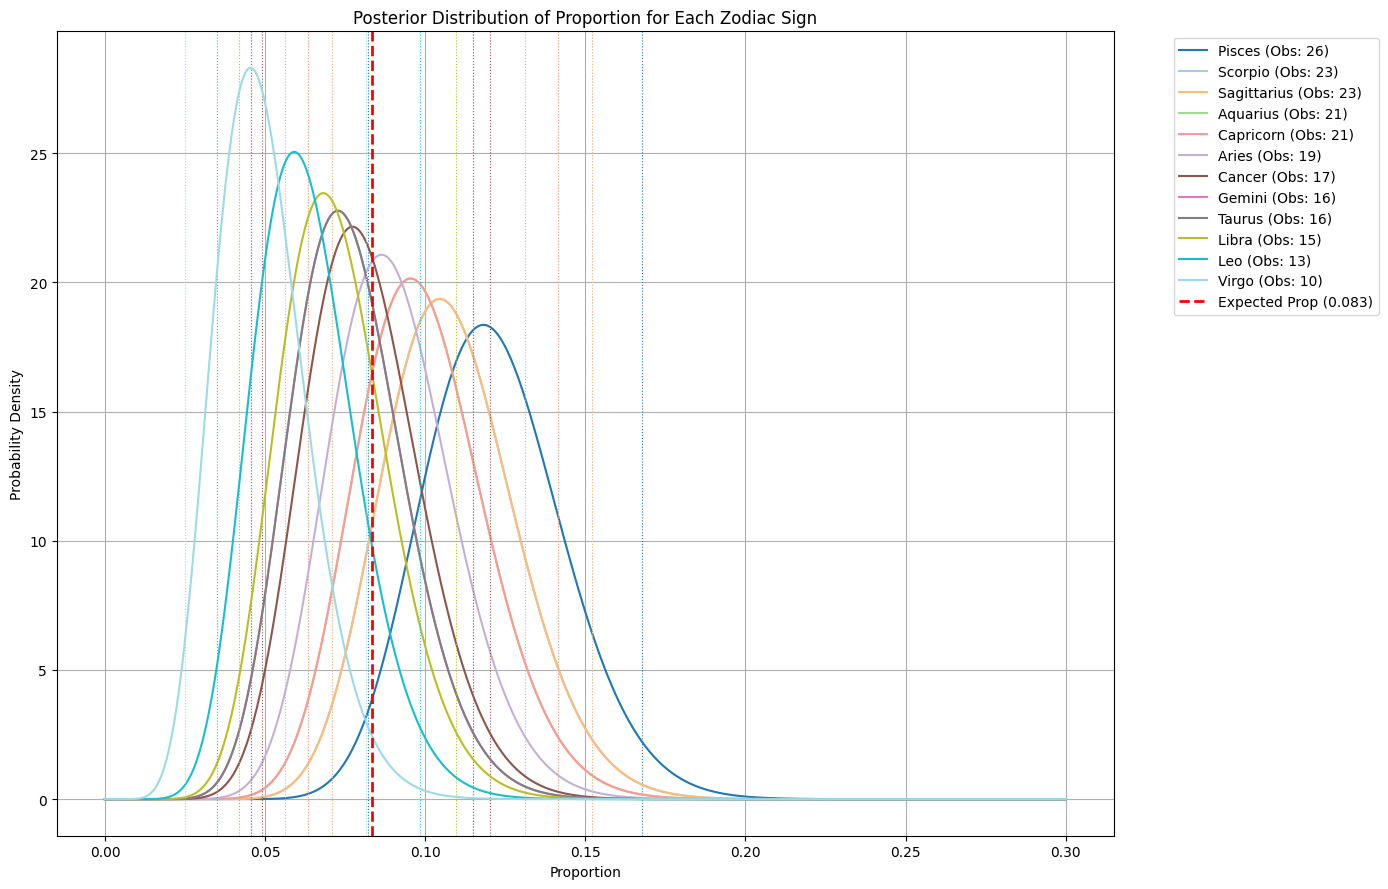


--- Bayesian Analysis Results for All Zodiac Signs ---

Знак зодіаку 'Pisces':
  Спостережена кількість: 26
  Апостеріорні параметри Beta: alpha=27, beta=195
  95% інтервал довіри для пропорції: (0.082, 0.168)
  Очікувана пропорція (рівномірний розподіл): 0.083
  Висновок: Очікувана пропорція знаходиться всередині 95% інтервалу довіри. Немає статистично значущої різниці.

Знак зодіаку 'Scorpio':
  Спостережена кількість: 23
  Апостеріорні параметри Beta: alpha=24, beta=198
  95% інтервал довіри для пропорції: (0.071, 0.152)
  Очікувана пропорція (рівномірний розподіл): 0.083
  Висновок: Очікувана пропорція знаходиться всередині 95% інтервалу довіри. Немає статистично значущої різниці.

Знак зодіаку 'Sagittarius':
  Спостережена кількість: 23
  Апостеріорні параметри Beta: alpha=24, beta=198
  95% інтервал довіри для пропорції: (0.071, 0.152)
  Очікувана пропорція (рівномірний розподіл): 0.083
  Висновок: Очікувана пропорція знаходиться всередині 95% інтервалу довіри. Немає статистично

In [8]:
from scipy.stats import beta
import matplotlib.pyplot as plt
import numpy as np

# Get all unique zodiac signs
zodiac_names = zodiac_counts.index.tolist()

# Set up plot for all signs
plt.figure(figsize=(14, 9))

# Get a colormap with enough distinct colors for 12 signs
colors = plt.cm.get_cmap('tab20', len(zodiac_names))

# Апріорні параметри Beta-розподілу (наприклад, Beta(1,1) для рівномірного апріорі)
alpha_prior = 1
beta_prior = 1

results = []

for i, sign_to_test_bayes in enumerate(zodiac_names):
    observed_count_bayes = zodiac_counts[sign_to_test_bayes]
    total_with_zodiac_bayes = zodiac_counts.sum()

    alpha_posterior = alpha_prior + observed_count_bayes
    beta_posterior = beta_prior + (total_with_zodiac_bayes - observed_count_bayes)

    lower_bound, upper_bound = beta.interval(0.95, alpha_posterior, beta_posterior)
    expected_prop = 1 / num_zodiac_signs

    in_ci = lower_bound <= expected_prop <= upper_bound
    flag = "" if in_ci else "⚠️ підозрілий"

    results.append({
        'Sign': sign_to_test_bayes,
        'Observed Count': observed_count_bayes,
        'Alpha Posterior': alpha_posterior,
        'Beta Posterior': beta_posterior,
        '95% CI Lower': lower_bound,
        '95% CI Upper': upper_bound,
        'Expected Proportion': expected_prop,
        'In CI': in_ci
    })

    # Plot posterior distribution for each sign with a unique color
    x_bayes = np.linspace(0, 0.3, 500) # Adjust x-axis range for better visibility
    plt.plot(x_bayes, beta.pdf(x_bayes, alpha_posterior, beta_posterior), label=f'{sign_to_test_bayes} (Obs: {observed_count_bayes})', color=colors(i))
    plt.axvline(lower_bound, color=colors(i), linestyle=':', linewidth=0.8)
    plt.axvline(upper_bound, color=colors(i), linestyle=':', linewidth=0.8)

plt.axvline(expected_prop, color='red', linestyle='--', label=f'Expected Prop ({expected_prop:.3f})', linewidth=2)
plt.title('Posterior Distribution of Proportion for Each Zodiac Sign')
plt.xlabel('Proportion')
plt.ylabel('Probability Density')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n--- Bayesian Analysis Results for All Zodiac Signs ---")
for res in results:
    print(f"\nЗнак зодіаку '{res['Sign']}':")
    print(f"  Спостережена кількість: {res['Observed Count']}")
    print(f"  Апостеріорні параметри Beta: alpha={res['Alpha Posterior']}, beta={res['Beta Posterior']}")
    print(f"  95% інтервал довіри для пропорції: ({res['95% CI Lower']:.3f}, {res['95% CI Upper']:.3f})")
    print(f"  Очікувана пропорція (рівномірний розподіл): {res['Expected Proportion']:.3f}")
    if res['In CI']:
        print(f"  Висновок: Очікувана пропорція знаходиться всередині 95% інтервалу довіри. Немає статистично значущої різниці.")
    else:
        print(f"  Висновок: Очікувана пропорція знаходиться поза 95% інтервалом довіри. \"Відрізняється\" від очікуваної пропорції.")

Bayesian analysis показує, що майже всі знаки зодіаку мають частки, які узгоджуються з рівномірним розподілом.
Єдине незначне відхилення спостерігається для Virgo, однак воно знаходиться на межі статистичної похибки і, ймовірно, є випадковим.


Висновок: жодної реальної залежності немає, і всі три підходи (χ², binomial, Bayesian) це узгоджено підтверджують.